### Scenario with noise
#### Variables
- Noise probability 
- with different channel types (different noise types)

The idea is to inject noise after when Alice sends qubits but before Bob measures

In [1]:
import random
import numpy as np

#### **Bit flip**
The principle is when the qubit flips from |0> to |1> or vice versa, when measured in the computational state, with some specific probability. The bit flip errors are modeled by applying the X gate. 

In [2]:
def bit_flip(qubit, p):
    if random.random()<p:
        return 1-qubit
    return qubit

#### **Depolarizing channel**
This channel describes the process in which a 1 qubit quantum state loses its quantum information and decays into an incoherent mixture of the computational basis states, |0><0| or |1><1|.  The quantum state loses the phase as well as the superposition between basis states.

In [3]:
def depolarizing(qubit,p):
    if random.random()<p:
        return random.choice([0,1])
    return qubit

#### **Photon loss**
The case where we simply lose a photon

In [4]:
def photon_loss(qubit, p):
    if random.random()<p:
        return None
    return qubit

In [5]:
def run_bb84_noisy(n, noise_type, p):
    alice_bits=[random.randint(0,1) for _ in range(n)]
    alice_bases=[random.choice(['Z','X']) for _ in range(n)]
    bob_bases=[random.choice(['Z','X']) for _ in range(n)]
    transmitted=[]
    for bit in alice_bits:
        noisy_bit=noise_type(bit,p)
        transmitted.append(noisy_bit)
    bob_res=[]
    for i in range(n):
        q=transmitted[i]
        if q is None:
            bob_res.append(None)
            continue
        if alice_bases[i]==bob_bases[i]:
            bob_res.append(q)
        else:
            bob_res.append(random.randint(0,1))
    
    sift_alice=[]
    sift_bob=[]
    for i in range(n):
        if alice_bases[i]==bob_bases[i] and transmitted[i] is not None:
            sift_alice.append(alice_bits[i])
            sift_bob.append(bob_res[i])
    return sift_alice, sift_bob


In [6]:
def qber_calc(alice_key, bob_key):
    if len(alice_key)==0:
        return 0
    return np.sum(alice_key!=bob_key)/len(alice_key)

In [7]:
def key_generation_rate(sifted_len, total_qubs):
    return sifted_len/total_qubs

In [8]:
def run_experiments_noisy(n=1000, runs=100):
    #percent of noise
    noise_lvl=[i/100 for i in range(0,21,2)] 
    types={
        "bit_flip":bit_flip,
        "depolarizing": depolarizing,
        "photon_loss": photon_loss
    }
    results={}
    for type_name, type_func in types.items():
        results[type_name]=[]
        for p in noise_lvl:
            qbers=[]
            kgrs=[]
            for _ in range(runs):
                a,b=run_bb84_noisy(n, type_func, p)
                qber=qber_calc(a,b)
                kgr=key_generation_rate(len(a), n)
                qbers.append(qber)
                kgrs.append(kgr)
            results[type_name].append({
                "p":p,
                "avg_qber":sum(qbers)/len(qbers),
                "avg_kgr":sum(kgrs)/len(kgrs)
            })
    return results

In [9]:
import matplotlib.pyplot as plt

def plot_qber(results):
    for model in results:
        ps = [x["p"] for x in results[model]]
        qbers = [x["avg_qber"] for x in results[model]]
        
        plt.plot(ps, qbers, label=model)

    plt.xlabel("Noise Probability")
    plt.ylabel("QBER")
    plt.title("QBER vs Noise Level")
    plt.legend()
    plt.grid()
    plt.show()

In [17]:
def plot_kgr(results):
    for model in results:
        ps = [x["p"] for x in results[model]]
        rates = [x["avg_kgr"] for x in results[model]]
        
        plt.plot(ps, rates, label=model)

    plt.xlabel("Noise Probability")
    plt.ylabel("Key Rate")
    plt.title("Key Rate vs Noise")
    plt.legend()
    plt.grid()
    plt.show()

=== Ideal Channel Results ===


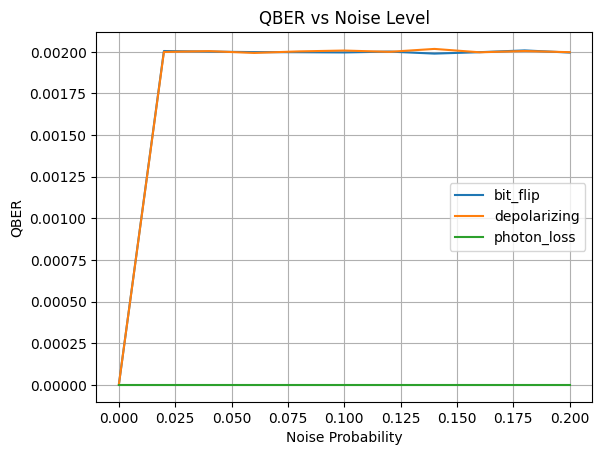

In [15]:
results = run_experiments_noisy()

print("=== Ideal Channel Results ===")
plot_qber(results)


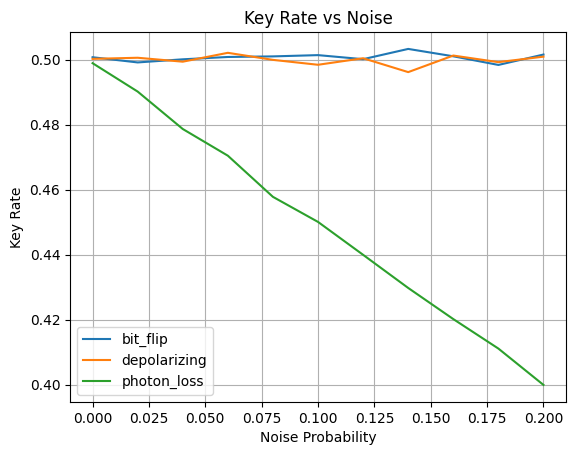

In [18]:
plot_kgr(results)

#### Useful links
- https://aws.amazon.com/fr/blogs/quantum-computing/noise-in-quantum-computing/   
